In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Estadística avanzada (te lo van a pedir después)
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 👇 IMPORTANTE: usamos TU conexión, no engine
from scripts.load_to_postgres import conectar

# Estilo visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías listas")

✅ Librerías listas


In [3]:
# ── CELDA 2: Cargar datos desde PostgreSQL ────────────────────

conn = conectar()

query = """
SELECT
    name,
    capital,
    region,
    subregion,
    population,
    area,
    latitude,
    longitude,
    density,
    fecha_extraccion
FROM countries
"""

df = pd.read_sql(query, conn)

conn.close()

print("✅ Datos cargados correctamente")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.head()

✅ Datos cargados correctamente
Filas: 246
Columnas: 10


/tmp/ipykernel_1681/3327327372.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,name,capital,region,subregion,population,area,latitude,longitude,density,fecha_extraccion
0,Ivory Coast,Yamoussoukro,Africa,Western Africa,31719275,322463.0,8.000000,-5.000000,98.365626,2026-04-14 16:56:47.771989
1,Italy,Rome,Europe,Southern Europe,58927633,301336.0,42.833333,12.833333,195.554574,2026-04-14 16:56:47.772016
2,Kyrgyzstan,Bishkek,Asia,Central Asia,7281800,199951.0,41.000000,75.000000,36.417922,2026-04-14 16:56:47.772023
3,Papua New Guinea,Port Moresby,Oceania,Melanesia,11781559,462840.0,-6.000000,147.000000,25.454928,2026-04-14 16:56:47.772027
4,Fiji,Suva,Oceania,Melanesia,900869,18272.0,-17.713400,178.065000,49.303251,2026-04-14 16:56:47.772032


In [4]:
# ── CELDA 3: Inspección del dataset ──────────────────────────

print("=" * 50)
print("INFO DATASET")
print("=" * 50)

print(df.info())

print("\n📊 Valores nulos:")
print(df.isnull().sum())

print("\n🌍 Regiones:")
print(df['region'].value_counts())

INFO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   name              246 non-null    str           
 1   capital           246 non-null    str           
 2   region            246 non-null    str           
 3   subregion         246 non-null    str           
 4   population        246 non-null    int64         
 5   area              246 non-null    float64       
 6   latitude          246 non-null    float64       
 7   longitude         246 non-null    float64       
 8   density           246 non-null    float64       
 9   fecha_extraccion  246 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(4), int64(1), str(4)
memory usage: 28.3 KB
None

📊 Valores nulos:
name                0
capital             0
region              0
subregion           0
population          0
area                0
latitude    

In [5]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────

vars_num = ['population', 'area', 'density', 'latitude', 'longitude']

desc = df[vars_num].describe().round(2)

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
         population         area   density  latitude  longitude
count  2.460000e+02       246.00    246.00    246.00     246.00
mean   3.259678e+07    553899.28    351.10     17.39      13.60
std    1.329749e+08   1725754.76   1460.13     25.54      74.43
min    0.000000e+00         0.49      0.00    -54.50    -176.20
25%    2.707250e+05      1592.00     30.71      1.38     -54.50
50%    5.334165e+06     65455.00     88.45     16.64      17.50
75%    2.065734e+07    384150.50    234.39     39.00      48.75
max    1.417492e+09  17098246.00  19021.29     78.00     178.06


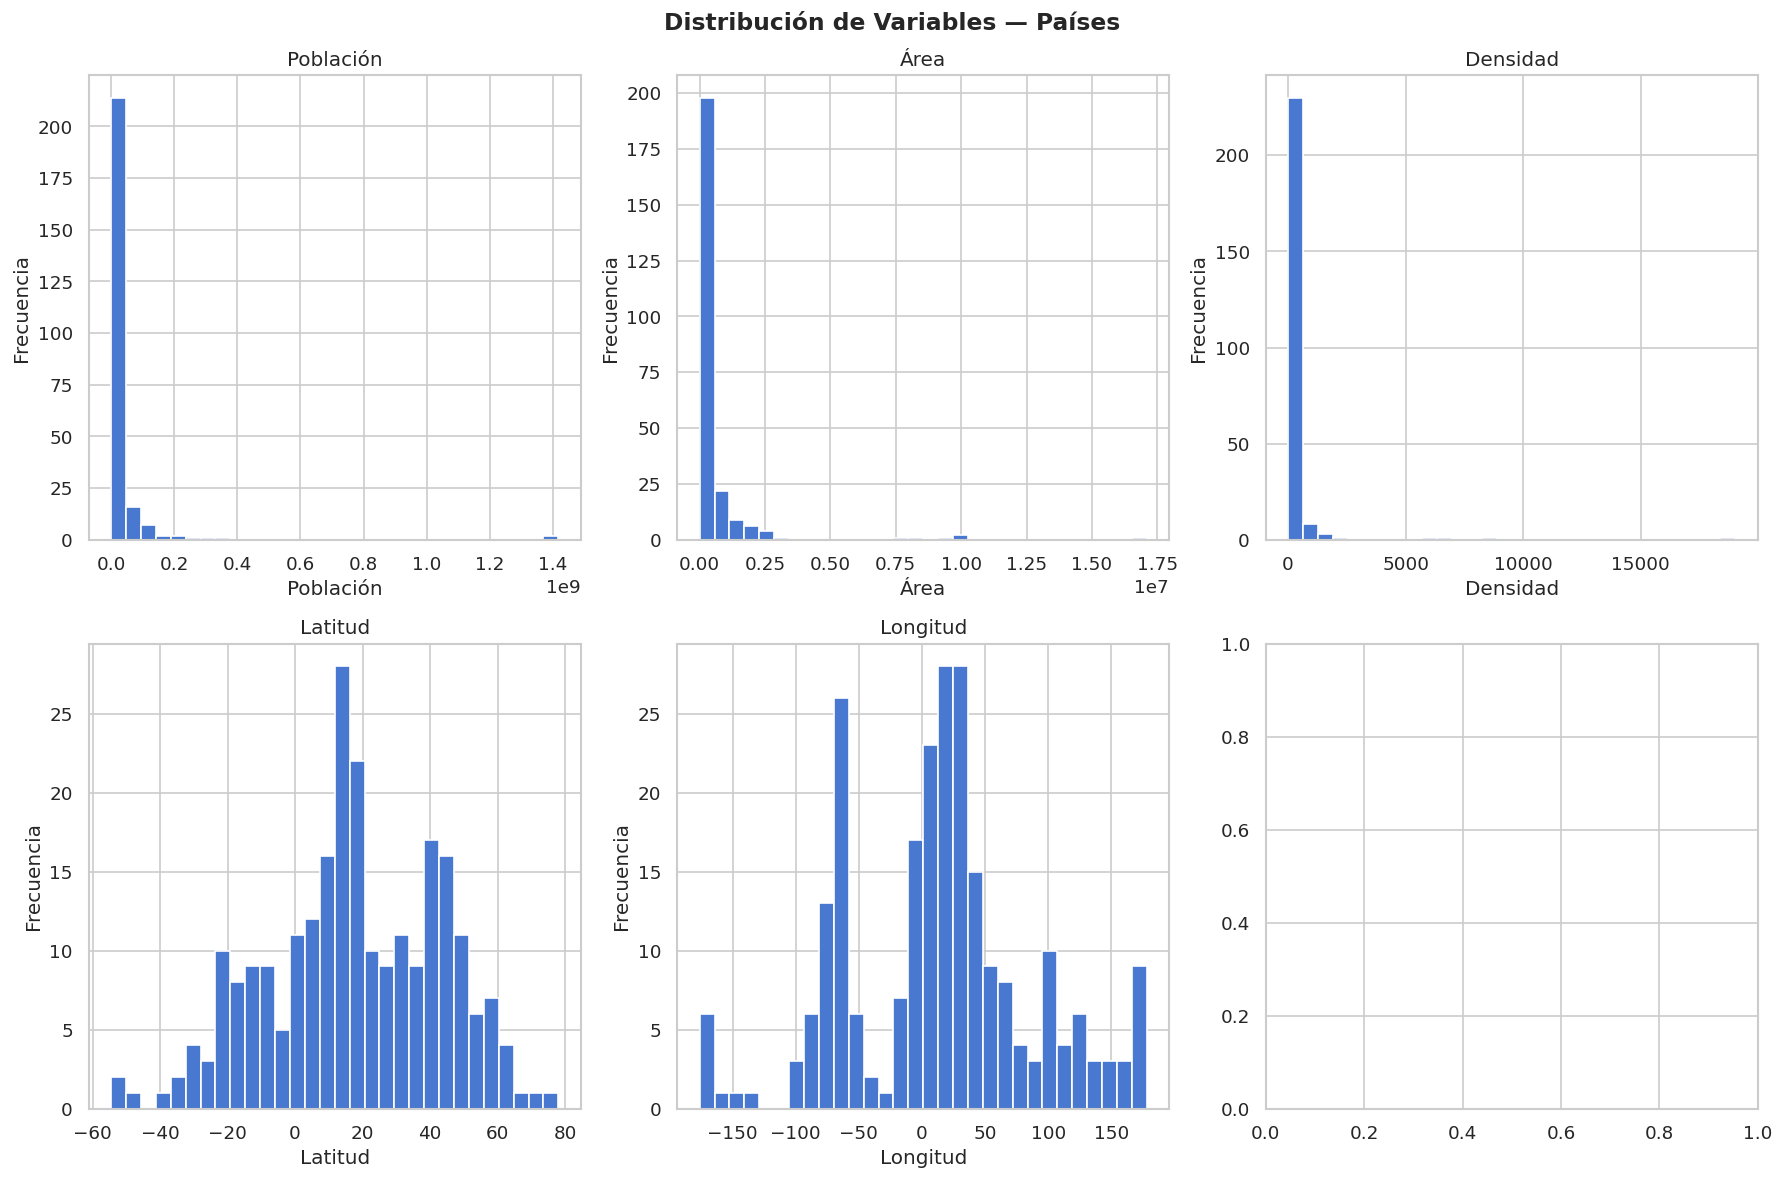

In [6]:
# ── CELDA 5: Distribución de variables ─────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribución de Variables — Países',
             fontsize=14, fontweight='bold')

datos = [
    ('population', 'Población'),
    ('area', 'Área'),
    ('density', 'Densidad'),
    ('latitude', 'Latitud'),
    ('longitude', 'Longitud')
]

for ax, (col, label) in zip(axes.flat, datos):
    ax.hist(df[col], bins=30, edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

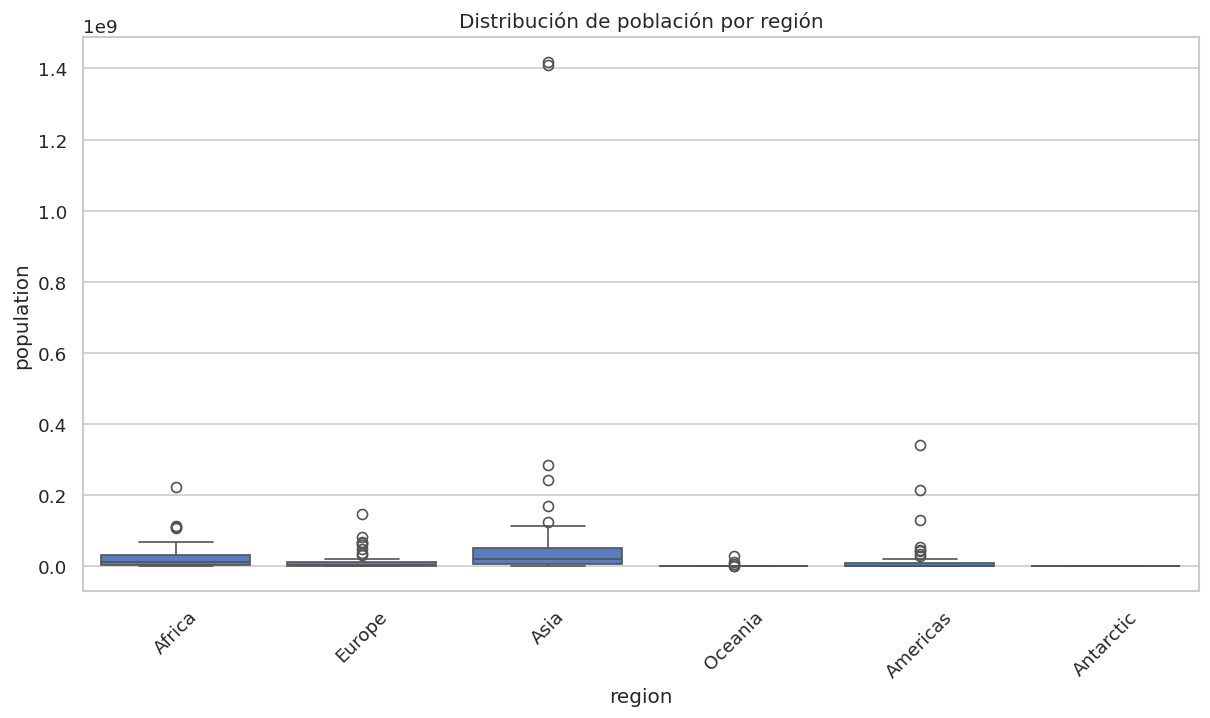

In [6]:
# ── CELDA 6: Boxplot por región ─────────────────────────────

plt.figure(figsize=(12,6))

sns.boxplot(data=df, x='region', y='population')
plt.xticks(rotation=45)
plt.title("Distribución de población por región")

plt.show()

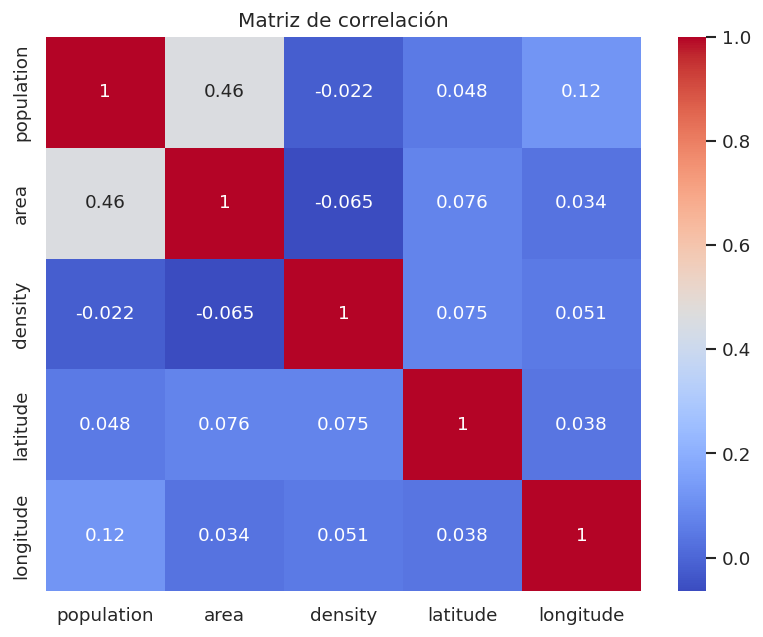


📊 Correlación con density:
density       1.000000
latitude      0.075204
longitude     0.050784
population   -0.021691
area         -0.064503
Name: density, dtype: float64


In [7]:
# ── CELDA 7: Matriz de correlación ───────────────────────────

corr = df[vars_num].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")

plt.show()

print("\n📊 Correlación con density:")
print(corr['density'].sort_values(ascending=False))

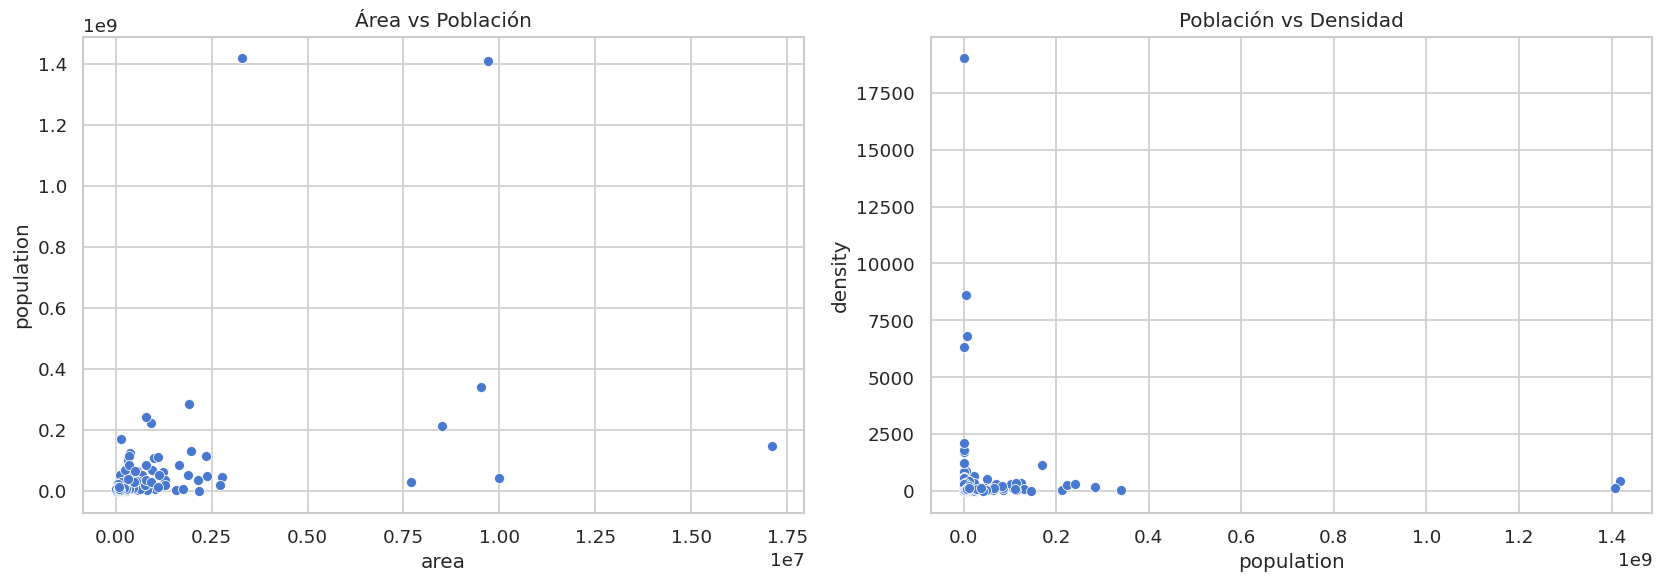

In [7]:
# ── CELDA 8: Relaciones ─────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(x='area', y='population', data=df, ax=axes[0])
axes[0].set_title("Área vs Población")

sns.scatterplot(x='population', y='density', data=df, ax=axes[1])
axes[1].set_title("Población vs Densidad")

plt.tight_layout()
plt.show()

In [9]:
# ── CELDA 9 ───────────────────────────────────────────────

X_simple = df[['population']].values
y = df['density'].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test : {X_test.shape[0]} muestras")

Train: 196 muestras
Test : 50 muestras


In [10]:
# ── CELDA 10 ───────────────────────────────────────────────

from sklearn.linear_model import LinearRegression

modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto β₀: {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁: {modelo_simple.coef_[0]:.4f}")

print(f"\nEcuación:")
print(f"density = {modelo_simple.intercept_:.3f} + {modelo_simple.coef_[0]:.6f} * population")

Intercepto β₀: 350.4438
Coeficiente β₁: -0.0000

Ecuación:
density = 350.444 + -0.000000 * population


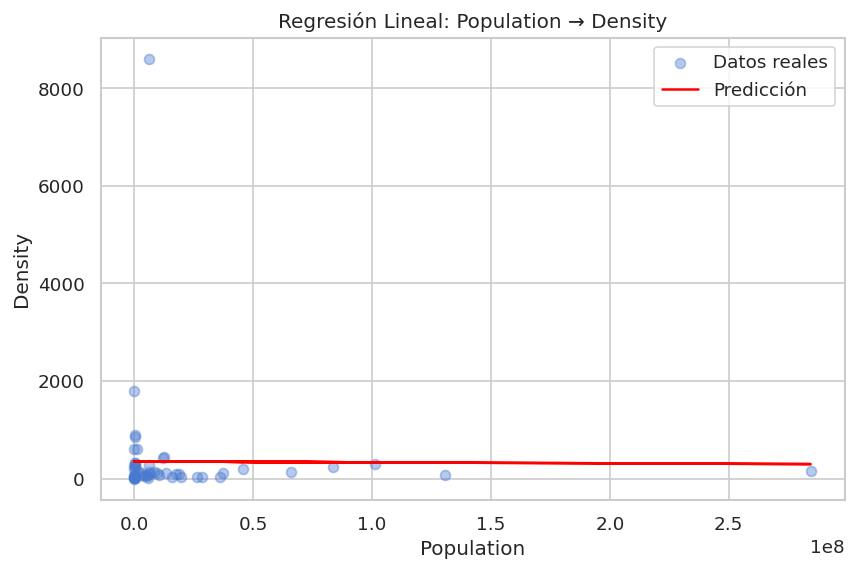

In [11]:
# ── CELDA 11 ───────────────────────────────────────────────

plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test, alpha=0.4, label="Datos reales")
plt.plot(X_test, y_pred_simple, color='red', label="Predicción")

plt.xlabel("Population")
plt.ylabel("Density")
plt.title("Regresión Lineal: Population → Density")

plt.legend()
plt.show()

In [12]:
# ── CELDA 12 ───────────────────────────────────────────────

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

r2 = r2_score(y_test, y_pred_simple)
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)

print("MÉTRICAS")
print(f"R2: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

MÉTRICAS
R2: 0.0001
MSE: 1471863.0236
RMSE: 1213.2036
MAE: 422.8537


In [13]:
# ── CELDA 13 ───────────────────────────────────────────────

import statsmodels.api as sm

X_ols = sm.add_constant(df['population'])
modelo_ols_simple = sm.OLS(df['density'], X_ols).fit()

print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                density   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.1149
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.735
Time:                        20:50:39   Log-Likelihood:                -2140.9
No. Observations:                 246   AIC:                             4286.
Df Residuals:                     244   BIC:                             4293.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        358.8621     96.035      3.737      0.0

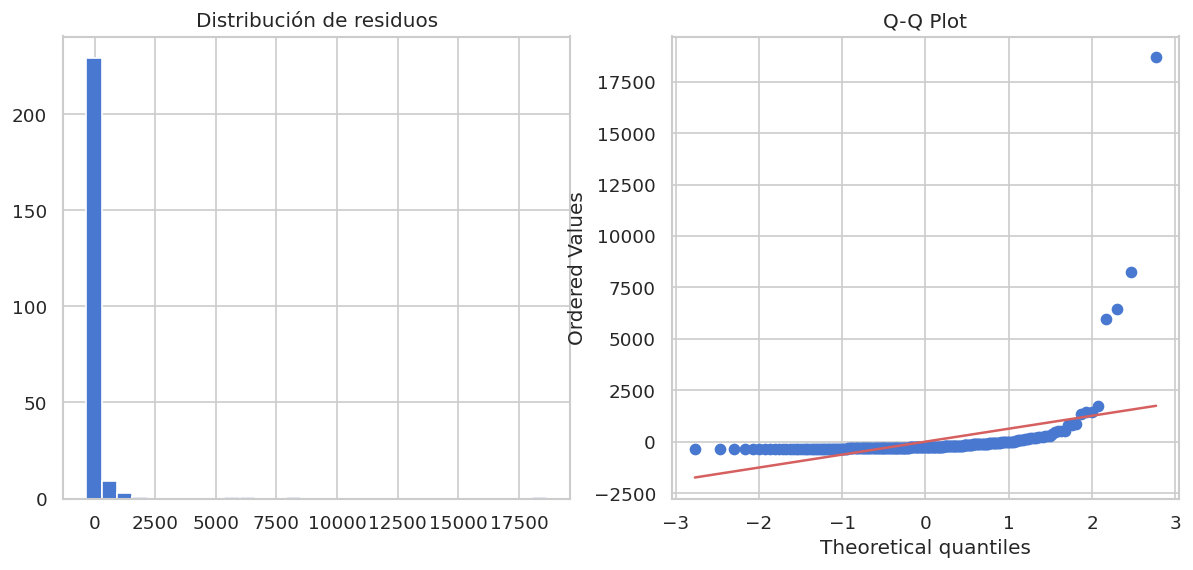

p-value: 0.00000
⚠️ No normales


In [14]:
# ── CELDA 14 ───────────────────────────────────────────────

# Predicción sobre todo el dataset
y_pred_all = modelo_simple.predict(df[['population']].values)

# Residuos
residuos = df['density'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Histograma
axes[0].hist(residuos, bins=30)
axes[0].set_title("Distribución de residuos")

# Q-Q Plot
from scipy import stats
stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot")

plt.show()

# Test Shapiro
stat, p = stats.shapiro(residuos)

print(f"p-value: {p:.5f}")

if p > 0.05:
    print("✅ Residuos normales")
else:
    print("⚠️ No normales")

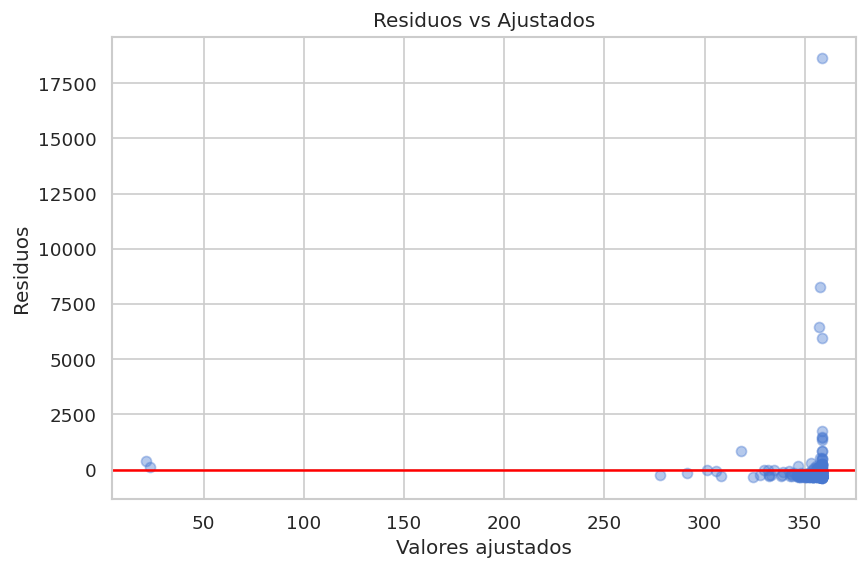

p-value: 0.74215
✅ Homocedasticidad


In [15]:
# ── CELDA 15 ───────────────────────────────────────────────

residuos_ols = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(8,5))

plt.scatter(ajustados_ols, residuos_ols, alpha=0.4)
plt.axhline(0, color='red')

plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs Ajustados")

plt.show()

# Test Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

lm, lm_p, fval, fp = het_breuschpagan(
    residuos_ols,
    modelo_ols_simple.model.exog
)

print(f"p-value: {lm_p:.5f}")

if lm_p > 0.05:
    print("✅ Homocedasticidad")
else:
    print("⚠️ Heterocedasticidad")